In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import os

# ============================================================
# PARAMETERS
# ============================================================

SAMPLE_RATE       = 1e9
EVENT_WINDOW      = 2e-6
SAMPLES_PER_EVENT = int(SAMPLE_RATE * EVENT_WINDOW)

NUM_EVENTS        = 5000
TOTAL_SAMPLES     = NUM_EVENTS * SAMPLES_PER_EVENT

ADC_BITS          = 14
ADC_MAX           = (2**ADC_BITS) - 1

BASELINE          = 2000
NOISE_SIGMA_MIN   = 10
NOISE_SIGMA_MAX   = 50

PULSE_HEIGHT_MIN  = 150
PULSE_HEIGHT_MAX  = 2000

PULSE_WIDTH       = 25

PROB_NOISE        = 0.33
PROB_SINGLE       = 0.34
PROB_DOUBLE       = 0.33

SPACING_MIN       = 80
SPACING_MAX       = 300

# ============================================================
# PULSE SHAPES
# ============================================================

def gaussian_pulse(center, width, height, N):
    x = np.arange(N)
    return height * np.exp(-((x - center) ** 2) / (2 * width ** 2))


def landau_approx(center, width, height, N):
    x = np.arange(N)
    t = (x - center) / width
    pulse = np.zeros(N)
    for i, ti in enumerate(t):
        val = np.exp(-0.5 * (ti + np.exp(-ti)))
        pulse[i] = height * val
    return pulse

# ============================================================
# SINGLE WINDOW GENERATOR
# ============================================================

def generate_event(pulse_shape='gaussian'):
    noise_sigma = random.uniform(NOISE_SIGMA_MIN, NOISE_SIGMA_MAX)
    segment = np.random.normal(BASELINE, noise_sigma, SAMPLES_PER_EVENT)

    r = random.random()

    if r < PROB_NOISE:
        label = 0
        metadata = {'peaks': [], 'amplitudes': []}

    elif r < PROB_NOISE + PROB_SINGLE:
        label = 1
        amplitude = random.uniform(PULSE_HEIGHT_MIN, PULSE_HEIGHT_MAX)
        center = random.randint(50, SAMPLES_PER_EVENT - 50)

        if pulse_shape == 'landau':
            segment += landau_approx(center, PULSE_WIDTH, amplitude, SAMPLES_PER_EVENT)
        else:
            segment += gaussian_pulse(center, PULSE_WIDTH, amplitude, SAMPLES_PER_EVENT)

        metadata = {'peaks': [center], 'amplitudes': [amplitude]}

    else:
        label = 2
        amp1 = random.uniform(PULSE_HEIGHT_MIN, PULSE_HEIGHT_MAX)
        amp2 = random.uniform(PULSE_HEIGHT_MIN, PULSE_HEIGHT_MAX)

        spacing = random.randint(SPACING_MIN, SPACING_MAX)
        peak1 = random.randint(50, SAMPLES_PER_EVENT - SPACING_MAX - 50)
        peak2 = peak1 + spacing

        if pulse_shape == 'landau':
            segment += landau_approx(peak1, PULSE_WIDTH, amp1, SAMPLES_PER_EVENT)
            segment += landau_approx(peak2, PULSE_WIDTH, amp2, SAMPLES_PER_EVENT)
        else:
            segment += gaussian_pulse(peak1, PULSE_WIDTH, amp1, SAMPLES_PER_EVENT)
            segment += gaussian_pulse(peak2, PULSE_WIDTH, amp2, SAMPLES_PER_EVENT)

        metadata = {'peaks': [peak1, peak2], 'amplitudes': [amp1, amp2]}

    return segment, label, metadata

# ============================================================
# MAIN GENERATION LOOP
# ============================================================

def generate_dataset(num_events=NUM_EVENTS, pulse_shape='gaussian', seed=42):
    np.random.seed(seed)
    random.seed(seed)

    waveforms = np.zeros((num_events, SAMPLES_PER_EVENT))
    labels = np.zeros(num_events, dtype=int)
    all_metadata = []

    for i in range(num_events):
        segment, label, meta = generate_event(pulse_shape=pulse_shape)
        waveforms[i] = segment
        labels[i] = label
        all_metadata.append(meta)

    waveforms = np.clip(waveforms, 0, ADC_MAX).astype(np.int16)

    return waveforms, labels, all_metadata

# ============================================================
# EXPORT FUNCTIONS
# ============================================================

def save_mem_file(waveforms, filename):
    flat = waveforms.flatten()
    with open(filename, 'w') as f:
        for value in flat:
            f.write('{:04x}\n'.format(int(value)))
    print(f'Saved {filename} ({len(flat)} samples)')


def save_numpy(waveforms, labels, filename_prefix):
    np.save(f'{filename_prefix}_waveforms.npy', waveforms)
    np.save(f'{filename_prefix}_labels.npy', labels)
    print(f'Saved {filename_prefix}_waveforms.npy: shape {waveforms.shape}')
    print(f'Saved {filename_prefix}_labels.npy:    shape {labels.shape}')

# ============================================================
# VISUALIZATION
# ============================================================

def plot_examples(waveforms, labels, output_dir, n_per_class=3):
    class_names = {0: 'Noise Only', 1: 'Single Peak', 2: 'Double Peak'}
    fig, axes = plt.subplots(3, n_per_class, figsize=(14, 8))
    fig.suptitle('Example Waveforms by Class', fontsize=14)

    for cls in range(3):
        idxs = np.where(labels == cls)[0][:n_per_class]
        for j, idx in enumerate(idxs):
            ax = axes[cls][j]
            ax.plot(waveforms[idx], linewidth=0.8, color='steelblue')
            ax.set_title(f'{class_names[cls]}', fontsize=10)
            ax.set_xlabel('Sample')
            ax.set_ylabel('ADC')
            ax.set_ylim(0, ADC_MAX)
            ax.axhline(BASELINE, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'waveform_examples.png'), dpi=150)
    plt.show()
    print('Saved waveform_examples.png')


def plot_class_distribution(labels, output_dir):
    class_names = ['Noise Only', 'Single Peak', 'Double Peak']
    counts = [np.sum(labels == i) for i in range(3)]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(class_names, counts, color=['gray', 'steelblue', 'darkorange'])
    plt.title('Dataset Class Distribution')
    plt.ylabel('Count')
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 str(count), ha='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'class_distribution.png'), dpi=150)
    plt.show()
    print('Saved class_distribution.png')

Generating 5000 events...

Class counts:
  Noise Only: 1679
  Single Peak: 1689
  Double Peak: 1632
Saved /Users/giannalongo/Downloads/pioneer/476_Final/waveform.mem (200000 samples)
Saved /Users/giannalongo/Downloads/pioneer/476_Final/dataset_waveforms.npy: shape (5000, 2000)
Saved /Users/giannalongo/Downloads/pioneer/476_Final/dataset_labels.npy:    shape (5000,)


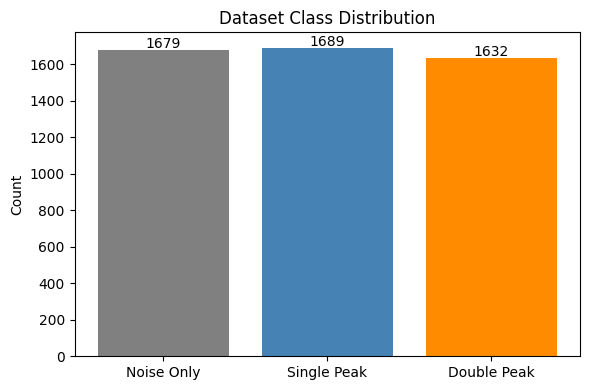

Saved class_distribution.png


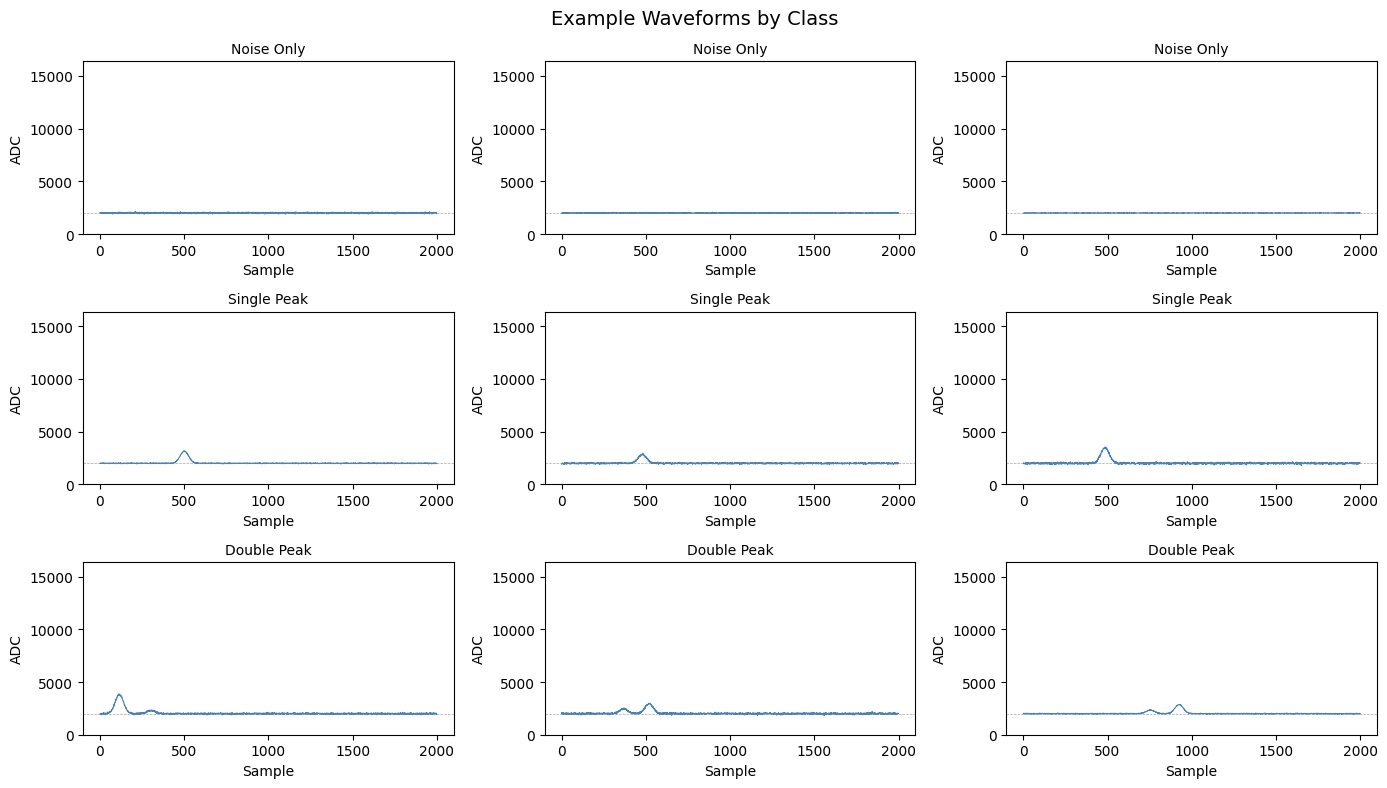

Saved waveform_examples.png


In [6]:
OUTPUT_DIR = '/Users/giannalongo/Downloads/pioneer/476_Final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Generating {NUM_EVENTS} events...')
waveforms, labels, metadata = generate_dataset(num_events=NUM_EVENTS, pulse_shape='gaussian', seed=42)

print(f'\nClass counts:')
for cls, name in enumerate(['Noise Only', 'Single Peak', 'Double Peak']):
    print(f'  {name}: {np.sum(labels == cls)}')

save_mem_file(waveforms[:100], os.path.join(OUTPUT_DIR, 'waveform.mem'))
save_numpy(waveforms, labels, os.path.join(OUTPUT_DIR, 'dataset'))
plot_class_distribution(labels, output_dir=OUTPUT_DIR)
plot_examples(waveforms, labels, output_dir=OUTPUT_DIR, n_per_class=3)